# 🧠 Deep Learning Practical Assignment (Adult Income Dataset)

## 📌 Dataset
We will use the **Adult Income dataset** (also known as the Census Income dataset).  
The task is to predict whether a person earns **more than $50K/year** based on demographic and employment attributes.

---


In [1]:
# Option 1: Using OpenML via scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd

# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print(df.head())
print(df.shape)  # (48842, 15)

# Separate features and target
X = df.drop(columns="class")
y = df["class"]


   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

## Part 0: Data Preparation
1. Load the dataset into a DataFrame.
2. Split the data into **training, validation, and test sets**.  
   - Suggested: 70% training, 15% validation, 15% test.
3. Apply any necessary preprocessing:
   - Handle categorical features (encoding).
   - Scale numerical features if needed.
4. After training your models, always report results on:
   - **Training accuracy**
   - **Validation accuracy**
   - **Test accuracy**
5. At the end of the assignment, **compare all methods** across train, validation, and test sets.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [3]:
df = pd.concat([X,y] , axis =1)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
# printing the train data
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
# printing some information about the train data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [6]:
# checking for missing values
df.isna().sum() 

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [7]:
# checking the shape of the data
df.shape

(48842, 15)

In [8]:
# dropping the missing values
df.dropna(axis=0 , inplace = True)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [9]:
# douple checking for missing values
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64

In [10]:
# checking for duplicates
df.duplicated().sum()

47

In [11]:
# droping duplicated rows
df.drop_duplicates(inplace=True)

In [12]:
# douple checking for duplicates
df.duplicated().sum()

0

In [13]:
# check categorical features for inconsistancy
for col in df.select_dtypes(include='category'):
    print(f'{col} : {df[col].unique()}')
    print('----------------------------------')
    

workclass : ['Private', 'Local-gov', 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay']
Categories (8, object): ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']
----------------------------------
education : ['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th', ..., '9th', 'Doctorate', '12th', '1st-4th', 'Preschool']
Length: 16
Categories (16, object): ['10th', '11th', '12th', '1st-4th', ..., 'Masters', 'Preschool', 'Prof-school', 'Some-college']
----------------------------------
marital-status : ['Never-married', 'Married-civ-spouse', 'Widowed', 'Separated', 'Divorced', 'Married-spouse-absent', 'Married-AF-spouse']
Categories (7, object): ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']
----------------------------------
occupation : ['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', 'Other-service', '

In [14]:
# print some summary statistical about the numerical features
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,45175.000000,4.517500e+04,45175.000000,45175.000000,45175.000000,45175.000000
mean,38.556170,1.897388e+05,10.119314,1102.576270,88.687593,40.942512
std,13.215349,1.056524e+05,2.551740,7510.249876,405.156611,12.007730
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173925e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783120e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379030e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


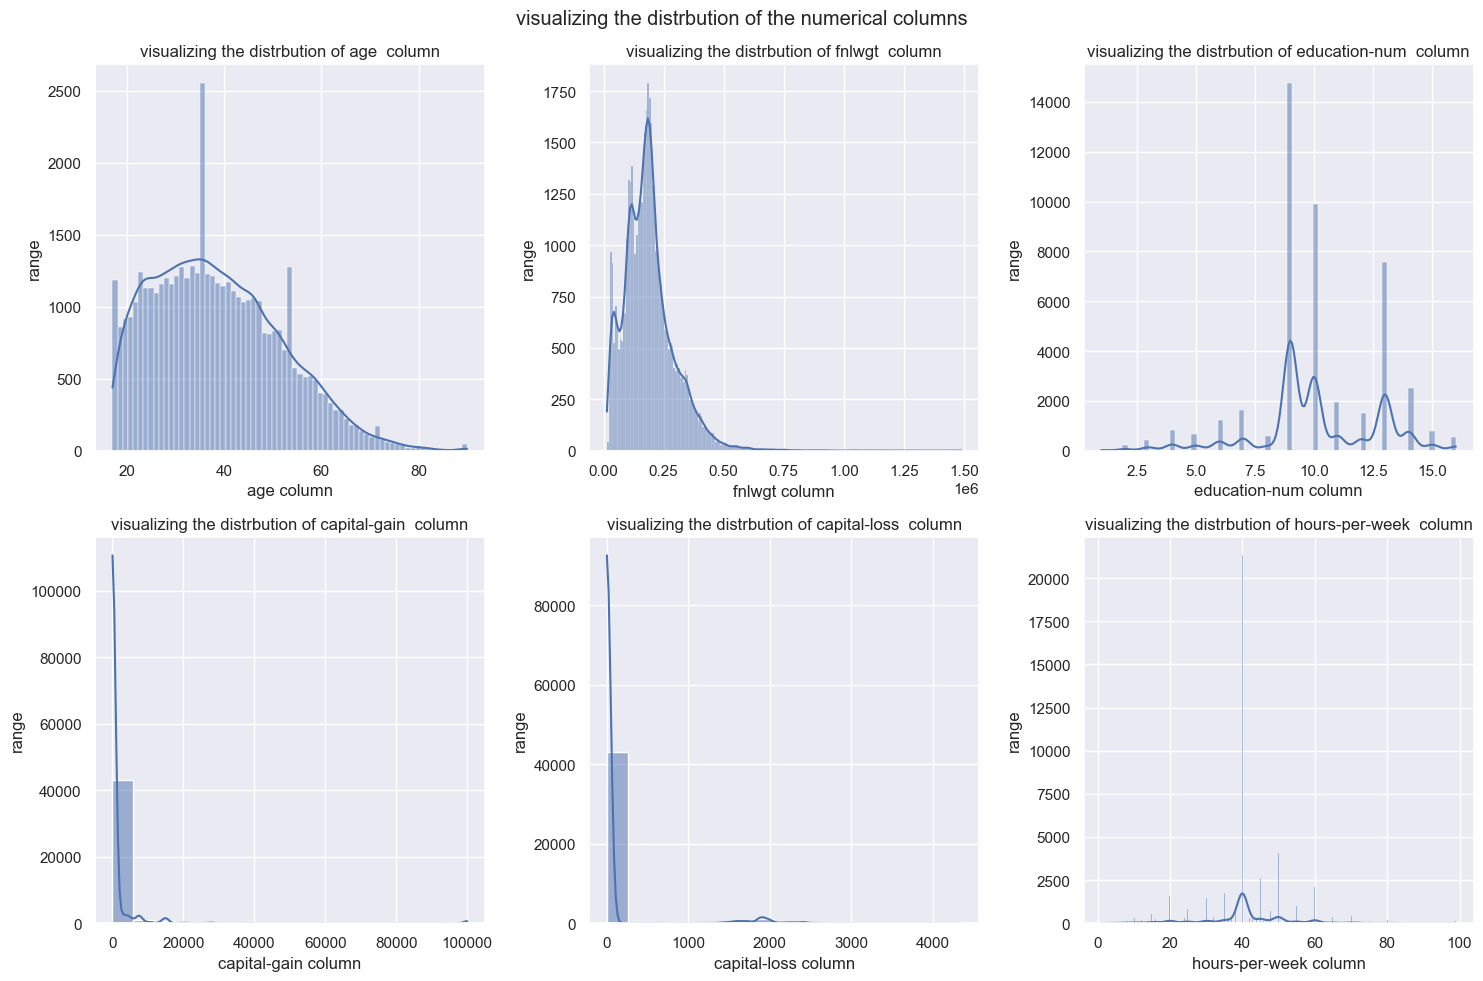

In [15]:
# visualizing the distribution of the numerical features
plt.figure(figsize = (15 , 10))
plt.suptitle('visualizing the distrbution of the numerical columns')
fig =1
for col in df.select_dtypes(exclude='category'):
    plt.subplot(2,3,fig)
    sns.histplot(data = df , x = col , kde=True)
    plt.title(f'visualizing the distrbution of {col}  column')
    plt.xlabel(f'{col} column')
    plt.ylabel('range')
    fig += 1
plt.tight_layout()
plt.show()

some columns have right skewed distribution and some have discrete values

splitting the data

In [16]:
X = df.drop(columns='class')
y = df['class']


In [17]:
# splitting the data
from sklearn.model_selection import train_test_split
# split 70% for train and 30% for test
x_train , x_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state=42 , stratify= y)
# split 15% for test and 15% for validation
x_test , x_val , y_test , y_val = train_test_split(x_test , y_test , random_state=42 , test_size=0.5 , stratify=y_test)

for encoding and scaling features i will use :
- one hot encoding for `sex` and `class` column
- ordinal encoding for `education` column
- target encoding for the rest of the categorical features
- for the discrete columns i will use min max scaler
- for the skewed columns i will use log transform

In [18]:
# using one hot encoding to encode sex and class columns
from sklearn.preprocessing import OneHotEncoder
OHE = OneHotEncoder(drop ='first' )
ohe_df = OHE.fit_transform(pd.concat([x_train['sex' ], y_train] , axis =1))
ohe_df = pd.DataFrame(ohe_df.toarray() , columns = OHE.get_feature_names_out())
ohe_df

,sex_Male,class_>50K
0,0.0,0.0
1,1.0,1.0
2,1.0,0.0
3,0.0,0.0
4,1.0,0.0
...,...,...
31617,0.0,0.0
31618,0.0,1.0
31619,1.0,1.0
31620,1.0,0.0


In [19]:
# fitting one hot encoding on val and test data
ohe_val_df = OHE.transform(pd.concat([x_val['sex' ], y_val] , axis =1))
ohe_val_df = pd.DataFrame(ohe_val_df.toarray() , columns = OHE.get_feature_names_out())
ohe_test_df = OHE.transform(pd.concat([x_test['sex' ], y_test] , axis =1))
ohe_test_df = pd.DataFrame(ohe_test_df.toarray() , columns = OHE.get_feature_names_out())
ohe_test_df

,sex_Male,class_>50K
0,1.0,0.0
1,1.0,0.0
2,0.0,0.0
3,1.0,0.0
4,0.0,0.0
...,...,...
6771,1.0,1.0
6772,1.0,1.0
6773,0.0,0.0
6774,1.0,1.0


In [20]:
# encoding education column using ordinal encoding
from sklearn.preprocessing import OrdinalEncoder
education_levels = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate"
]
OE = OrdinalEncoder(categories = [education_levels])
oe_df = OE.fit_transform(x_train[['education']])
oe_df = pd.DataFrame(oe_df , columns= OE.get_feature_names_out())
oe_df

,education
0,8.0
1,10.0
2,9.0
3,9.0
4,12.0
...,...
31617,12.0
31618,9.0
31619,8.0
31620,8.0


In [21]:
# fitting ordinal encoder on val and test data
oe_val_df = OE.transform(x_val[['education']])
oe_val_df = pd.DataFrame(oe_val_df , columns= OE.get_feature_names_out())

oe_test_df = OE.transform(x_test[['education']])
oe_test_df = pd.DataFrame(oe_test_df , columns= OE.get_feature_names_out())
oe_test_df

,education
0,8.0
1,8.0
2,8.0
3,12.0
4,10.0
...,...
6771,15.0
6772,12.0
6773,9.0
6774,12.0


In [ ]:
from category_encoders import TargetEncoder
columns = ['workclass' , 'marital-status' , 'occupation' , 'relationship' , 'race' , 'native-country']
target_encoder = TargetEncoder(cols=columns)
target_encoded_df = target_encoder.fit_transform(x_train, y_train)
target_encoded_df = target_encoded_df[columns]
target_encoded_df

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [ ]:
x_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
41190,32,Private,232855,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Black,Female,0,0,40,United-States
24270,47,Local-gov,174533,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States
1755,38,Private,161141,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,55,United-States
10188,39,Private,186719,Some-college,10,Separated,Craft-repair,Unmarried,White,Female,0,0,25,United-States
38051,23,Federal-gov,53245,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42781,53,Private,264939,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,45,Mexico
6312,23,State-gov,89285,Some-college,10,Never-married,Protective-serv,Not-in-family,Other,Female,99999,0,40,United-States
33794,46,Federal-gov,78022,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States
29215,24,Private,229773,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States



## Part 1: Optimizers
1. Train the same neural network using:
   - Stochastic Gradient Descent (SGD)
   - SGD with Momentum
   - Adam
2. Compare the training and validation accuracy for each optimizer.
3. Which optimizer converges the fastest? Which gives the best generalization?
4. Explain *why* Adam often performs better than plain SGD.

---


## Part 2: Batch Size
1. Train the same model with different batch sizes (e.g., 1, 32, 128, 1024).
2. Compare:
   - Training speed
   - Validation accuracy
   - Test accuracy
   - Generalization ability
3. Which batch size leads to the **noisiest gradient updates**?
4. Which batch size generalizes better and why?


## Part 3: Overfitting and Regularization
1. Train a large neural network (many parameters) on the dataset.
2. Observe training vs. validation accuracy.  
   - Do you see signs of overfitting?
3. Apply regularization techniques:
   - **L2 regularization**
   - **Dropout**
4. Compare the validation results before and after regularization.
5. Which regularization method was more effective in reducing overfitting? Why?

---


## Part 4: Early Stopping
1. Train the model for many epochs without early stopping.  
   - Plot training, validation, and test curves.
2. Train again with **early stopping** (monitor validation loss).
3. Compare the number of epochs trained and the final validation/test accuracy.
4. Explain how early stopping helps prevent overfitting.

---

## Part 5: Reflection
1. Summarize what you learned about:
   - The role of optimizers
   - The effect of batch size
   - Regularization methods
   - Early stopping
   - Train/validation/test splits
2. If you had to train a deep learning model on a new tabular dataset, what choices would you make for:
   - Optimizer
   - Batch size
   - Regularization
   - Early stopping
   - Data splitting strategy  
   and why?